In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
df=pd.read_csv(r"C:\Users\BADRI SAMEERA\OneDrive\Desktop\House_Prediction.csv")
df.head(5)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,02-05-2014 00:00,313000.0,3,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,02-05-2014 00:00,2384000.0,5,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,02-05-2014 00:00,342000.0,3,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,02-05-2014 00:00,420000.0,3,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,02-05-2014 00:00,550000.0,4,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [3]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')

In [ ]:
X = df.drop("LoanAmount", axis=1)
y = df["LoanAmount"]
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target :", y_test.shape)
print("Training Data")
print(X_train.head())
print("\nTesting Data")
print(X_test.head())

In [4]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Features and target
X = df.drop("price", axis=1)
y = df["price"]

# Convert categorical columns into numerical columns
X = pd.get_dummies(X, drop_first=True)

# Split the dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Print the shapes
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target :", y_test.shape)

# Display training data
print("\nTraining Data")
print(X_train.head())

# Display testing data
print("\nTesting Data")
print(X_test.head())

Training Features: (3680, 4724)
Testing Features : (920, 4724)
Training Target: (3680,)
Testing Target : (920,)

Training Data
      bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
1898         4       2.50         2770     45514     2.0           0     0   
1370         4       3.00         3720     29043     2.0           0     0   
3038         4       2.50         2810     11120     2.0           0     0   
2361         4       3.75         4030     10800     2.0           0     0   
156          3       2.00         2000      7000     2.0           0     0   

      condition  sqft_above  sqft_basement  ...  statezip_WA 98155  \
1898          4        2770              0  ...              False   
1370          3        3720              0  ...              False   
3038          3        2810              0  ...              False   
2361          3        4030              0  ...              False   
156           3        2000              0  ...       

In [5]:
df["price"]

0       3.130000e+05
1       2.384000e+06
2       3.420000e+05
3       4.200000e+05
4       5.500000e+05
            ...     
4595    3.081667e+05
4596    5.343333e+05
4597    4.169042e+05
4598    2.034000e+05
4599    2.206000e+05
Name: price, Length: 4600, dtype: float64

In [6]:
df["bedrooms"]

0       3
1       5
2       3
3       3
4       4
       ..
4595    3
4596    3
4597    3
4598    4
4599    3
Name: bedrooms, Length: 4600, dtype: int64

In [7]:
import numpy as np

# Select columns
X = df["sqft_living"]
Y = df["price"]

# Calculate slope
m = ((X - X.mean()) * (Y - Y.mean())).sum() / ((X - X.mean()) ** 2).sum()

# Calculate intercept
c = Y.mean() - m * X.mean()

# Predict price
Y_pred = m * X + c

print(Y_pred)

# Round the predicted values
Y_pred = np.round(Y_pred).astype(int)

print(Y_pred.head())

# Print slope and intercept
print("Slope:", m)
print("Intercept:", c)

0       350567.418016
1       932572.220762
2       499217.995341
3       516854.504515
4       501737.496651
            ...      
4595    393398.940296
4596    380801.433743
4597    771324.136884
4598    539530.016310
4599    388359.937675
Name: sqft_living, Length: 4600, dtype: float64
0    350567
1    932572
2    499218
3    516855
4    501737
Name: sqft_living, dtype: int64
Slope: 251.95013105919185
Intercept: 12954.242396307993


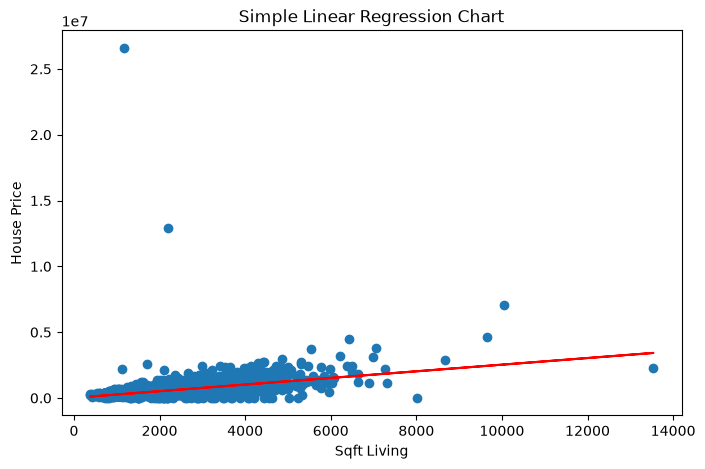

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Scatter plot
plt.scatter(X, Y)

# Regression line
plt.plot(X, Y_pred, color="red")

# Chart title and labels
plt.title("Simple Linear Regression Chart")
plt.xlabel("Sqft Living")
plt.ylabel("House Price")

plt.show()

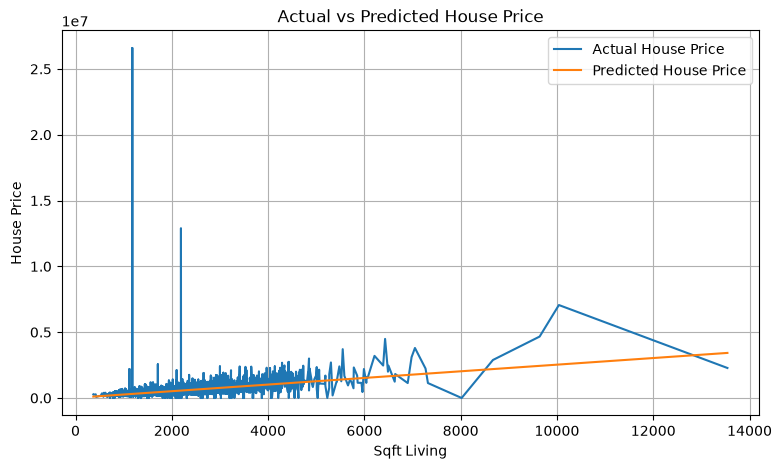

In [9]:
# Create a DataFrame with X, actual price, and predicted price
sorted_data = pd.DataFrame({
    "X": X,
    "Actual": Y,
    "Predicted": Y_pred
}).sort_values("X")

# Create the graph
plt.figure(figsize=(9, 5))

plt.plot(
    sorted_data["X"],
    sorted_data["Actual"],
    label="Actual House Price"
)

plt.plot(
    sorted_data["X"],
    sorted_data["Predicted"],
    label="Predicted House Price"
)

# Add title and labels
plt.title("Actual vs Predicted House Price")
plt.xlabel("Sqft Living")
plt.ylabel("House Price")

plt.legend()
plt.grid(True)

plt.show()

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load the dataset
df = pd.read_csv(
    r"C:\Users\BADRI SAMEERA\OneDrive\Desktop\House_Prediction.csv"
)

# Display first 5 rows
print(df.head())

# Select input and target columns
X = df[["sqft_living"]]
y = df["price"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Create the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Display intercept and slope
print("Intercept (b0):", model.intercept_)
print("Slope (b1):", model.coef_[0])

# Display the regression equation
print("\nRegression Equation:")
print(
    f"House Price = {model.intercept_} + "
    f"{model.coef_[0]} * Sqft Living"
)

# Predict house prices
y_pred = model.predict(X_test)

# Round the predicted values
y_pred = np.round(y_pred).astype(int)

# Create a results table
result = pd.DataFrame({
    "Sqft Living": X_test["sqft_living"].values,
    "Actual House Price": y_test.values,
    "Predicted House Price": y_pred
})

# Display the first 10 results
print("\nActual and Predicted Values:")
print(result.head(10))

# Create data for the graph
plot_data = pd.DataFrame({
    "Sqft Living": X_test["sqft_living"].values,
    "Actual House Price": y_test.values,
    "Predicted House Price": y_pred
})

# Sort values for a proper regression-line graph
plot_data = plot_data.sort_values("Sqft Living")

# Plot actual

               date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  02-05-2014 00:00   313000.0         3       1.50         1340      7912   
1  02-05-2014 00:00  2384000.0         5       2.50         3650      9050   
2  02-05-2014 00:00   342000.0         3       2.00         1930     11947   
3  02-05-2014 00:00   420000.0         3       2.25         2000      8030   
4  02-05-2014 00:00   550000.0         4       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated                    street       city  st